In [1]:



######PLEASE NOTE!!! IMAGES HERE ARE FROM THE DEMO DATA!! PLEASE SEE THE OUTPUTS FOR THE REAL RESULTS!


# Temperature Trends Analysis - Main Notebook
# CMPT 353 Final Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.dataset as ds
from sklearn.linear_model import LinearRegression
from scipy import stats
import json
from scipy.stats import theilslopes
from matplotlib.colors import TwoSlopeNorm
from statsmodels.nonparametric.smoothers_lowess import lowess



# RANDOM_STATE = 42
# N_TARGET = 100 
# # N_TARGET = 300 
# USE_ALL_QUALIFYING = False  





# Set to true for githib sample data, false for full analysis pls
DEMO_MODE = True

RANDOM_STATE = 42
USE_ALL_QUALIFYING = False

if DEMO_MODE:
    print("RUNNING IN DEMO MODE. Usnig sample data and relaxed thresholds")

    N_TARGET = 25
    MIN_YEARS = 6          
    MIN_COMPLETENESS = 0.7 
    MIN_WEEKS = 200        
    MAX_DISTANCE = 75       
    
    MIN_WEEKS_TOTAL = 30       
    MIN_MONTHS = 8             
    MIN_WEEKS_PER_SEASON = 4  
    weather_dir = Path("../data/samples/weather_weekly_with_city_dated_sample")
    
else:
    print("RUNNING IN PRODUCTION MODE")
    

    N_TARGET = 100
    MIN_YEARS = 15
    MIN_COMPLETENESS = 0.8
    MIN_WEEKS = 400
    MAX_DISTANCE = 50
    

    MIN_WEEKS_TOTAL = 47
    MIN_MONTHS = 11
    MIN_WEEKS_PER_SEASON = 8
    

    weather_dir = Path("../data/processed/weather_weekly_with_city_dated")




np.random.seed(RANDOM_STATE)


Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/tables").mkdir(parents=True, exist_ok=True)

print("Temperature Trends Analysis Project")



def preserve_iso_week_dates(df):
    df = df.copy()
    df["week_start"] = pd.to_datetime(df["week_start"])
    df["year"] = df["year"].astype("int16")
    if "week" in df.columns:
        df["week"] = df["week"].astype("int16")
    return df


def remove_duplicate_city_weeks(df):
    
   
    df["_valid_temps"] = df[["tmax_c", "tmin_c"]].notna().all(axis=1).astype(int)
    df["distance_km"] = pd.to_numeric(df["distance_km"], errors="coerce").fillna(999)

  
    df_clean = df.sort_values([
        "city_name", "country_code", "year", "week", "_valid_temps", "distance_km"
    ], ascending=[True, True, True, True, False, True])
    

    df_clean = df_clean.drop_duplicates([
        "city_name", "country_code", "year", "week"
    ], keep="first")
    df_clean = df_clean.drop(columns=["_valid_temps"])

    return df_clean


def aggregate_to_annual_with_seasonal_balance(df, min_weeks=47, min_months=11, min_weeks_per_season=8):
   
    # Convert weekly data to annual averages wiht seasonal balacne requirements.
    # This prevents bias from missing winter/summer data in extreme climates.
   
    print("Convertig to annual data with seasonal balance controls right now:")
    print("Cuurent requirements: >= ", min_weeks, "weeks/year, >= ", min_months, "months, >=", min_weeks_per_season, "weeks/season")

   
    df_prep = df.copy()
    df_prep["week_start_dt"] = pd.to_datetime(df_prep["week_start"])
    df_prep["month"] = df_prep["week_start_dt"].dt.month

   
    def assign_met_season_year(row):
        month = row["month"]
        year = row["year"]

        if month == 12:  # december belongs to next year
            met_year = year + 1
            season = "DJF"
        elif month in [1, 2]:  # jan, feb belong to current year
            met_year = year
            season = "DJF"
        elif month in [3, 4, 5]:
            met_year = year
            season = "MAM"
        elif month in [6, 7, 8]:
            met_year = year
            season = "JJA"
        else:  # Sept, Oct, Nov
            met_year = year
            season = "SON"

        return pd.Series([met_year, season])

    df_prep[["met_year", "season"]] = df_prep.apply(assign_met_season_year, axis=1)

    
    # Cout how many week sin eahc city, year, season
    # then pivot to add a seaosn info in each row
    seasonal_coverage = df_prep.groupby([
        "city_name", "country_code", "met_year", "season"
    ], as_index=False)["week"].count()
    seasonal_coverage = seasonal_coverage.rename(columns={"week": "weeks_in_season"})
    

    
    seasonal_pivot = seasonal_coverage.pivot_table(
        index=["city_name", "country_code", "met_year"],
        columns="season", values="weeks_in_season", fill_value=0
    ).reset_index()



    # makign sure all four season columsn exits. 
    for season in ["DJF", "MAM", "JJA", "SON"]:
        if season not in seasonal_pivot.columns:
            seasonal_pivot[season] = 0

    
    # city, year passes the season balacne if each seaosn has >= min weeks per season
    seasonal_pivot["min_seasonal_weeks"] = seasonal_pivot[["DJF", "MAM", "JJA", "SON"]].min(axis=1)
    seasonal_pivot["seasonally_balanced"] = (
        seasonal_pivot["min_seasonal_weeks"] >= min_weeks_per_season
    )

    
    print("\nKeeping city, year that passes the season balance\n")
    balanced_years = seasonal_pivot[seasonal_pivot["seasonally_balanced"]][
        ["city_name", "country_code", "met_year"]
    ].copy()
    balanced_years = balanced_years.rename(columns={"met_year": "year"})

    df_balanced = df_prep.merge(balanced_years, on=["city_name", "country_code", "year"], how="inner")

    print("Seasonal balance filtering:\n")
    original_city_years = df_prep.groupby(["city_name", "country_code", "year"]).ngroups
    print("Original city-years:", original_city_years)
    print("Seasonally balanced:", len(balanced_years))
    print("Retention rate:", round(len(balanced_years) / original_city_years * 100, 1), "%")

    annual_data = df_balanced.groupby([
        "city_name", "city_lat", "city_lon", "country_code", "year"
    ], as_index=False).agg({
        "temp_avg": "mean",
        "month": "nunique", 
        "season": "nunique",
        "tmax_c": "mean",
        "tmin_c": "mean", 
        "temp_range": "mean",
        "distance_km": "median"
    })
    
    
    # counting how many weeks have valid temp_avg in each city, year
    temp_weeks = df_balanced.groupby([
        "city_name", "city_lat", "city_lon", "country_code", "year"
    ])["temp_avg"].count().reset_index()
    temp_weeks = temp_weeks.rename(columns={"temp_avg": "valid_temp_weeks"})
    
    
    # Join the valid weeks count to the annual table
    annual_data = annual_data.merge(temp_weeks, on=[
        "city_name", "city_lat", "city_lon", "country_code", "year"
    ])

    
    annual_data = annual_data.rename(columns={
        "month": "months_represented",
        "season": "seasons_represented"
    })
    annual_data = annual_data.round(3)

    final_mask = (
        (annual_data["valid_temp_weeks"] >= min_weeks) & 
        (annual_data["months_represented"] >= min_months)
    )

    before_final = len(annual_data)
    annual_data = annual_data[final_mask].copy()
    after_final = len(annual_data)

    print("Final quality filtering:")
    print("After seasonal balance:", before_final, "city-year combinations")
    print("After all filters:", after_final, "city-year combinations (", 
          round(after_final / before_final * 100, 1) if before_final > 0 else 0, "% retained)")

    # Create city-level coverage summary
    city_coverage = seasonal_pivot.groupby(["city_name", "country_code"]).agg({
        "met_year": "count",
        "seasonally_balanced": "sum",
        "min_seasonal_weeks": "mean"
    }).reset_index()
    city_coverage.columns = [
        "city_name", "country_code", "total_years_available", 
        "balanced_years", "avg_min_seasonal_weeks"
    ]
    city_coverage["balanced_fraction"] = (
        city_coverage["balanced_years"] / city_coverage["total_years_available"]
    )

    # Repotr cities with low seasonal balance
    low_balance = city_coverage[city_coverage["balanced_fraction"] < 0.7].sort_values("balanced_fraction")

    if len(low_balance) > 0:
        print("\nCities with < 70% seasonally balanced years flagged :")
        print(low_balance.head(10)[[
            "city_name", "total_years_available", "balanced_years", "balanced_fraction"
        ]].to_string(index=False))

    # Savin coverage diagnostics
    city_coverage.to_csv("../outputs/tables/city_seasonal_coverage.csv", index=False)
    print("Saved seasonal coverage diagnostics to ../outputs/tables/city_seasonal_coverage.csv")

    annual_data["year"] = annual_data["year"].astype("int16")
    return annual_data


def safe_linear_regression(X, y):
    # linear regression with safety checks
    # Makin sure data types are correct
    X_clean = X.astype("float64")
    y_clean = y.astype("float64")

    if not np.isfinite(X_clean).all() or not np.isfinite(y_clean).all():
        return np.nan, np.nan, np.nan, np.nan

    try:
        model = LinearRegression().fit(X_clean.reshape(-1, 1), y_clean)
        y_pred = model.predict(X_clean.reshape(-1, 1))

        slope = model.coef_[0]
        r2 = model.score(X_clean.reshape(-1, 1), y_clean)

        n = len(y_clean)
        if n > 2:
            y_err = y_clean - y_pred
            mse = np.sum(y_err**2) / (n - 2)
            s_err = np.sqrt(mse)
            x_centered = X_clean - X_clean.mean()
            x_sum_sq = np.sum(x_centered**2)

            if x_sum_sq > 0:
                s_slope = s_err / np.sqrt(x_sum_sq)
                t_stat = slope / s_slope if s_slope > 0 else np.nan
                p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2)) if not np.isnan(t_stat) else np.nan
            else:
                t_stat, p_value = np.nan, np.nan
        else:
            t_stat, p_value = np.nan, np.nan

        return slope, r2, t_stat, p_value

    except Exception:
        return np.nan, np.nan, np.nan, np.nan


def fix_json_export(data_dict):
   # Convert numpy types to Python types for JSON
    def convert_numpy_type(value):
        if hasattr(value, "item"):
            return value.item()
        if isinstance(value, (np.integer,)):
            return int(value)
        if isinstance(value, (np.floating,)):
            return float(value)
        if isinstance(value, (np.bool_,)):
            return bool(value)
        return value

    return {key: convert_numpy_type(val) for key, val in data_dict.items()}


# Load Weekly Weather Data


def load_weekly_weather_data(data_path):
    data_path = Path(data_path)
    if data_path.is_dir():
        dataset = ds.dataset(str(data_path), format="parquet") 
    else:
        dataset = ds.dataset([str(data_path)], format="parquet") 
    weather_data = dataset.to_table().to_pandas()
    return preserve_iso_week_dates(weather_data)

#  geting data


# had to hcnage to make room for better smapleing
# weather_dir = Path("../data/samples/weather_sation_with_city_sample.parquet")


print("Loading with the load_weekly_weather_data: ")
weather_data = load_weekly_weather_data(weather_dir)

# makign sur eim gettign juts the complete calendar years only
print("Filtring to calendar years 2000-2024: ")
weather_data = weather_data[
    (weather_data["year"] >= 2000) & (weather_data["year"] <= 2024)
].copy()
print("After year filtering:", len(weather_data), "records")

print("Loaded", len(weather_data), "weather records")
print("Cities:", weather_data["city_name"].nunique())
print("Date range:", weather_data["year"].min(), "-", weather_data["year"].max(), 
      "(", weather_data["year"].nunique(), "complete years)")



print(weather_data.head(8).to_string(index=False))


RUNNING IN DEMO MODE. Usnig sample data and relaxed thresholds
Temperature Trends Analysis Project
Loading with the load_weekly_weather_data: 
Filtring to calendar years 2000-2024: 
After year filtering: 61993 records
Loaded 61993 weather records
Cities: 100
Date range: 2000 - 2023 ( 9 complete years)
    station  station_lat  station_lon  elevation           name  year  week week_start    tmax_c    tmin_c  prcp_mm city_name country_code  city_lat  city_lon  distance_km
AR000087217   -29.382999   -66.817001      438.0 LA RIOJA AERO.  2000     1 2000-01-03 35.014286 21.128571      0.0  La Rioja           AR -29.41328 -66.85637     5.087518
AR000087217   -29.382999   -66.817001      438.0 LA RIOJA AERO.  2000     2 2000-01-10 33.228571 22.614286      1.0  La Rioja           AR -29.41328 -66.85637     5.087518
AR000087217   -29.382999   -66.817001      438.0 LA RIOJA AERO.  2000     3 2000-01-17 32.571429 21.228571     50.0  La Rioja           AR -29.41328 -66.85637     5.087518
AR0000872

In [2]:

# Load Station Mapping form the file

station_map_path = "../data/processed/station_to_city_map_calculated_with_the_week_dates_data.parquet"
station_map = pd.read_parquet(station_map_path)

print("Station mapping:", len(station_map), "stations")
print("Distance summary: mean=" + str(round(station_map["distance_km"].mean(), 1)) + "km, median=" + 
      str(round(station_map["distance_km"].median(), 1)) + "km")

Station mapping: 14797 stations
Distance summary: mean=14.2km, median=5.7km


In [3]:
# Assessing quality of cities using unique weks.

def assess_city_quality(weather_data):
    # Check data quality for each city
    print("Computing city quality on unique weeks:")

    wd = weather_data.copy()

    # Making a uniqeu week id by combingin year and week together. like 
    # year=2014, week= 52 becomes yearweek =201452
    wd["yearweek"] = wd["year"].astype(int) * 100 + wd["week"].astype(int)

    # Flagin valid temperature pairs helping indenitfy if both the max and mina re not null
    wd["valid_pair"] = wd[["tmax_c", "tmin_c"]].notna().all(axis=1).astype(int)

    # Collapseing multiple stations per city-week
    print("Collapsing multiple stations per city-week:")
    wk = wd.groupby([
        "city_name", "country_code", "city_lat", "city_lon", "yearweek"
    ], as_index=False).agg({
        "valid_pair": "max",
        "distance_km": "min"
    })
    wk = wk.rename(columns={"valid_pair": "has_valid", "distance_km": "min_distance"})

    print("Unique city-weeks after collapse:", len(wk))

    # Calculate city-level quality metrics
    print("Computin city-level qualtiy metrics:")
    city_quality = wk.groupby([
        "city_name", "country_code", "city_lat", "city_lon"
    ], as_index=False).agg({
        "yearweek": "nunique",
        "has_valid": "mean",
        "min_distance": "median"
    })
    
    yearweek_groups = wk.groupby([
        "city_name", "country_code", "city_lat", "city_lon"
    ])["yearweek"]
    
    city_quality["first_year"] = yearweek_groups.min().values // 100
    city_quality["last_year"] = yearweek_groups.max().values // 100
    city_quality["years_count"] = yearweek_groups.apply(lambda s: len(set(v // 100 for v in s))).values
    
    # Rename columns
    city_quality = city_quality.rename(columns={
        "yearweek": "total_weeks",
        "has_valid": "valid_week_fraction", 
        "min_distance": "station_distance"
    })

    print("Assessed: ", len(city_quality), "cities")
    return city_quality

city_quality = assess_city_quality(weather_data)

# better to change the hard coded figues test later. add globals latre.
# print("Quality Assessment Summary:")
# print("Cities with >=15 years:", (city_quality["years_count"] >= 15).sum())
# print("Cities with >=80% valid weeks:", (city_quality["valid_week_fraction"] >= 0.8).sum())
# print("Cities with >=400 total weeks:", (city_quality["total_weeks"] >= 400).sum())
# print("Cities with station <=50km:", (city_quality["station_distance"] <= 50).sum())


# makig chnages all over coz of teh demo mode!!
print("Cities with >=", MIN_YEARS, "years:", (city_quality["years_count"] >= MIN_YEARS).sum())
print("Cities with >=", round(MIN_COMPLETENESS*100), "% valid weeks:", (city_quality["valid_week_fraction"] >= MIN_COMPLETENESS).sum())
print("Cities with >=", MIN_WEEKS, "total weeks:", (city_quality["total_weeks"] >= MIN_WEEKS).sum())
print("Cities with station <=", MAX_DISTANCE, "km:", (city_quality["station_distance"] <= MAX_DISTANCE).sum())





print(city_quality.head(8).to_string(index=False))

Computing city quality on unique weeks:
Collapsing multiple stations per city-week:
Unique city-weeks after collapse: 44806
Computin city-level qualtiy metrics:
Assessed:  111 cities
Cities with >= 6 years: 94
Cities with >= 70 % valid weeks: 111
Cities with >= 200 total weeks: 103
Cities with station <= 75 km: 111
      city_name country_code  city_lat   city_lon  total_weeks  valid_week_fraction  station_distance  first_year  last_year  years_count
       Adjuntas           PR  18.16274  -66.72212          449             1.000000          8.105328        2000       2023            9
          Ascot           AU -36.70000  144.33333          469             1.000000          4.432783        2000       2023            9
Ban Huai I Huak           TH  18.07861   98.03500          463             0.987041         14.587491        2000       2023            9
      Behchokǫ̀           CA  62.80250 -116.04639          443             1.000000         71.082268        2000       2023       

In [4]:
# city selection with geographic balance to make sure i dont over/underreprsnt some areas.
# weekly stuff is good now mostly 

# might be makin too tight an d strict but it works f or now. will change later ig issue arises. 
def select_representative_cities(city_quality, min_years=15, min_completeness=0.8, min_weeks=400, max_distance=50):
    print("Applying selection criteria:")
    print("Critreia: >=", min_years, "years, >=", round(min_completeness*100), "% valid weeks , >=", min_weeks, "total weeks, <= ", max_distance, " km distance")

    # Apply quality filters
    good_cities = city_quality[
        (city_quality["years_count"] >= min_years) &
        (city_quality["valid_week_fraction"] >= min_completeness) &
        (city_quality["total_weeks"] >= min_weeks) &
        (city_quality["station_distance"] <= max_distance)
    ].copy()

    print("Cities meeting criteria (good_cities df chekc):", len(good_cities), " out of", len(city_quality))


    # Cna think about adding try catches here. can also add the USE_ALL_QUALIFYING but that will make the stuff eveb slowr

    # geographic sampling for balanced representation
    def assign_geographic_region(lat, lon):
        
        if lat >= 66.5:
            lat_band = "Arctic"
        elif lat >= 45:
            lat_band = "High Northern"
        elif lat >= 23.5:
            lat_band = "Mid Northern"
        elif lat >= 0:
            lat_band = "Tropical Northern"
        elif lat >= -23.5:
            lat_band = "Tropical Southern"
        elif lat >= -45:
            lat_band = "Mid Southern"
        else:
            lat_band = "High Southern"

      
        if lon >= -180 and lon < -30:
            lon_band = "Americas"
        elif lon >= -30 and lon < 60:
            lon_band = "Europe-Africa"
        elif lon >= 60 and lon < 150:
            lon_band = "Asia-Pacific"
        else:
            lon_band = "Pacific"

        return lat_band + " ; " + lon_band

    
    # Comute a region label for the cities
    good_cities["geo_region"] = good_cities.apply(
        lambda row: assign_geographic_region(row["city_lat"], row["city_lon"]), axis=1
    )

    # Quality score for ranking
    # Im makign sure that the year count carries highest weight 
    # then week fraction and and then the ditsacne from sation 
    # will tinker with later. not based on anythign
    good_cities["quality_score"] = (
        good_cities["years_count"] * 0.4 +
        good_cities["valid_week_fraction"] * 20 +
        (50 - good_cities["station_distance"].fillna(50)) * 0.1
    )

    # Balanced selection
    # Finiding how many to take per region to hit the  N_TARGET overall
    # Wont hit N_TRAGET exatc but will try ot be close as poss.
    







    regions = good_cities["geo_region"].unique()
    if len(regions) == 0:
        print("No regions survived quality filters")
        if DEMO_MODE:
            print("DEMO_MODE: Returning all quality cities without geographic balancing")
            return good_cities.head(min(20, len(good_cities)))
        else:
           
            return pd.DataFrame()


    target_per_region = max(1, N_TARGET // max(1, len(regions)))
    remainder = N_TARGET % max(1, len(regions))

   
    print("\nGeographic distribution of qualifying cities:")
    region_counts = good_cities["geo_region"].value_counts().sort_index()
    for region, count in region_counts.items():
        print(" ", region + ":", count, "cities")

    selected_cities = []
    regions_sorted = sorted(regions)

    for i, region in enumerate(regions_sorted):
        region_cities = good_cities[good_cities["geo_region"] == region]

        # Disrtibute remainder cities to first few regoins
        target_for_region = target_per_region + (1 if i < remainder else 0)

        # Take top cities by quality score from this region
        region_selected = region_cities.nlargest(
            min(target_for_region, len(region_cities)), "quality_score"
        )

        selected_cities.append(region_selected)
        print("Selected from", region + ":", len(region_selected), "cities")

    if selected_cities:
        final_cities = pd.concat(selected_cities, ignore_index=True)


        print("\nFinal selection balance:")
        print("\nTotal selected:", len(final_cities))

        # Hemisphere basedd balance
        final_cities["hemisphere"] = np.where(final_cities["city_lat"] >= 0, "North", "South")
        hemisphere_balance = final_cities["hemisphere"].value_counts()
        print("\nHemisphere balance:")
        for hemisphere, count in hemisphere_balance.items():
            print(" ", hemisphere + ":", count, "(", round(count / len(final_cities) * 100, 1), "%)")

        # Regional summary htough wont be perfect coz the data is not that much
        final_region_counts = final_cities["geo_region"].value_counts().sort_index()
        print("\nRegional distribution (using lon from data so not perfect):")
        for region, count in final_region_counts.items():
            print(" ", region + ":", count)

        return final_cities


# Run city selection
# final_cities = select_representative_cities(city_quality)



final_cities = select_representative_cities(
    city_quality, 
    min_years=MIN_YEARS, 
    min_completeness=MIN_COMPLETENESS, 
    min_weeks=MIN_WEEKS, 
    max_distance=MAX_DISTANCE
)



print("\nSelected", len(final_cities), "cities for analsyis")


display_cols = ["city_name", "country_code", "city_lat", "years_count", "valid_week_fraction", "total_weeks"]
print(final_cities[display_cols].head(8).to_string(index=False))


Applying selection criteria:
Critreia: >= 6 years, >= 70 % valid weeks , >= 200 total weeks, <=  75  km distance
Cities meeting criteria (good_cities df chekc): 93  out of 111

Geographic distribution of qualifying cities:
  Arctic ; Americas: 2 cities
  Arctic ; Europe-Africa: 2 cities
  High Northern ; Americas: 9 cities
  High Northern ; Asia-Pacific: 3 cities
  High Northern ; Europe-Africa: 8 cities
  High Southern ; Americas: 1 cities
  Mid Northern ; Americas: 17 cities
  Mid Northern ; Asia-Pacific: 2 cities
  Mid Northern ; Europe-Africa: 1 cities
  Mid Southern ; Americas: 4 cities
  Mid Southern ; Asia-Pacific: 13 cities
  Mid Southern ; Europe-Africa: 1 cities
  Mid Southern ; Pacific: 9 cities
  Tropical Northern ; Americas: 5 cities
  Tropical Northern ; Asia-Pacific: 6 cities
  Tropical Northern ; Europe-Africa: 2 cities
  Tropical Southern ; Asia-Pacific: 6 cities
  Tropical Southern ; Europe-Africa: 1 cities
  Tropical Southern ; Pacific: 1 cities
Selected from Arctic 

In [5]:
# Preparing and cleaning the subset data goteen from ealier.

def prepare_analysis_dataset(weather_data, selected_cities):
    # maijgn sure same name cities in a country dont clash eahc other.
    keys = selected_cities[["city_name", "country_code"]].drop_duplicates()
    analysis_data = weather_data.merge(keys, on=["city_name", "country_code"], how="inner").copy()

    # Sanity check coz i should get fewer rows here
    name_only_count = len(weather_data[weather_data["city_name"].isin(keys["city_name"])])
    if len(analysis_data) < name_only_count:
        print("\nMerging on name and country gives ", len(analysis_data), "rows vs", name_only_count, "with name-only")

   
    valid_temps = analysis_data[["tmax_c", "tmin_c"]].notna().all(axis=1)
    # Get temp data i need only wehn both max min present
    analysis_data["temp_avg"] = np.where(
        valid_temps, (analysis_data["tmax_c"] + analysis_data["tmin_c"]) / 2, np.nan
    )
    #  chec
    analysis_data["temp_range"] = np.where(
        valid_temps, analysis_data["tmax_c"] - analysis_data["tmin_c"], np.nan
    )

    return analysis_data

analysis_data = prepare_analysis_dataset(weather_data, final_cities)

# Ensure only 1 rcord per city -week
analysis_data = remove_duplicate_city_weeks(analysis_data)

print("Analysis dataset:", len(analysis_data), "records")
print("Date range:", analysis_data["year"].min(), "-", analysis_data["year"].max())
temp_valid_pct = analysis_data["temp_avg"].notna().mean()
print("Valid temperature records:", round(temp_valid_pct * 100, 1), "%")

print(analysis_data[["city_name", "year", "week", "temp_avg", "distance_km"]].head(8).to_string(index=False))



Merging on name and country gives  20979 rows vs 22376 with name-only
Analysis dataset: 10656 records
Date range: 2000 - 2023
Valid temperature records: 98.1 %
city_name  year  week  temp_avg  distance_km
 Adjuntas  2000     1 21.150000     8.105328
 Adjuntas  2000     2 20.207143     8.105328
 Adjuntas  2000     3 17.850000     8.105328
 Adjuntas  2000     4 19.407143     8.105328
 Adjuntas  2000     5 19.658333     8.105328
 Adjuntas  2000     6 19.921429     8.105328
 Adjuntas  2000     7 20.407143     8.105328
 Adjuntas  2000     8 19.921429     8.105328


In [6]:
# Annual aggregation

annual_data = aggregate_to_annual_with_seasonal_balance(
    analysis_data, 
    min_weeks=MIN_WEEKS_TOTAL, 
    min_months=MIN_MONTHS, 
    min_weeks_per_season=MIN_WEEKS_PER_SEASON
)


print("Annual data:", len(annual_data), "city-year combinations")
print("Cities:", annual_data["city_name"].nunique())

# print(annual_data.head(8))
print(annual_data.head(8).to_string(index=False))

Convertig to annual data with seasonal balance controls right now:
Cuurent requirements: >=  30 weeks/year, >=  8 months, >= 4 weeks/season

Keeping city, year that passes the season balance

Seasonal balance filtering:

Original city-years: 210
Seasonally balanced: 205
Retention rate: 97.6 %
Final quality filtering:
After seasonal balance: 207 city-year combinations
After all filters: 201 city-year combinations ( 97.1 % retained)

Cities with < 70% seasonally balanced years flagged :
 city_name  total_years_available  balanced_years  balanced_fraction
     Kaédi                     14               6           0.428571
    Tabora                     18               8           0.444444
 Ostrovnoy                     11               5           0.454545
 Uummannaq                     15               7           0.466667
  Qaqortoq                     17               8           0.470588
   Surigao                     18               9           0.500000
Strezhevoy                 

In [7]:
# per-city trend analysis
# Was having issues with just using OLS so had to use Theil Sen as well


# Fit both OLS and Theil-Sen trends for each city
def fit_temperature_trends_robust(annual_df):
    
    trend_results = []

    for city_name in annual_df["city_name"].unique():
        city_data = annual_df[annual_df["city_name"] == city_name].copy()

        # if len(city_data) < 10:  # minimium years for reliable trend
        #     continue

        city_info = city_data.iloc[0]

        # Prepare regresion data
        X = city_data["year"].to_numpy().astype("float64")
        y = city_data["temp_avg"].to_numpy().astype("float64")

        # Remove non-finite values
        valid_mask = np.isfinite(X) & np.isfinite(y)
        

        X_clean = X[valid_mask]
        y_clean = y[valid_mask]

        
        # OLS regression for r sq and p value
        ols_slope, ols_r2, ols_t_stat, ols_p_value = safe_linear_regression(X_clean, y_clean)

        # theil-son regression to get main trend estimate
        ts_slope, ts_intercept, _, _ = theilslopes(y_clean, X_clean)

        # Useing theil-son slope as primary estimate coz its better againt noisy data
        primary_slope = ts_slope


        early_period = city_data[city_data["year"] <= 2009]
        recent_period = city_data[city_data["year"] >= 2015]

        trend_results.append({
            "city_name": city_name,
            "country_code": city_info["country_code"],
            "latitude": city_info["city_lat"],
            "longitude": city_info.get("city_lon", np.nan),
            "station_distance_km": float(city_data["distance_km"].median()) if "distance_km" in city_data.columns else np.nan,
            "years_analyzed": len(city_data),
            "first_year": int(city_data["year"].min()),
            "last_year": int(city_data["year"].max()),
            "temp_trend_per_year": primary_slope,
            "temp_trend_per_decade": primary_slope * 10,
            "ols_trend_per_decade": ols_slope * 10, 
            "r_squared": ols_r2,
            "t_statistic": ols_t_stat,
            "p_value": ols_p_value,
            "significant_05": ols_p_value < 0.05 if not np.isnan(ols_p_value) else False,
            "temp_2000_2009": early_period["temp_avg"].mean() if len(early_period) > 0 else np.nan,
            "temp_2015_2024": recent_period["temp_avg"].mean() if len(recent_period) > 0 else np.nan,
            "mean_temp_all_years": city_data["temp_avg"].mean(),
            "temp_std_dev": city_data["temp_avg"].std(),
        })



    return pd.DataFrame(trend_results)

trends_df = fit_temperature_trends_robust(annual_data)
print("Trend analysis complete on:", len(trends_df), "cities")

Trend analysis complete on: 24 cities


In [8]:
# Summary o fthe analysis completed

warming_cities = (trends_df["temp_trend_per_decade"] > 0).sum()
total_cities = len(trends_df)

# (p < 0.05)
significant_trends = trends_df["significant_05"].sum()

mean_trend = trends_df["temp_trend_per_decade"].mean()
median_trend = trends_df["temp_trend_per_decade"].median()


print("\nSummary of analysis completed:\n")
print("\nCities warming:", warming_cities, " out of ", total_cities, "(", round(warming_cities / total_cities * 100, 1), "%)")
print("\nSignificat trends:", significant_trends)
print("\nMean trend:", round(mean_trend, 3), "degC/decade")
print("Median trend:", round(median_trend, 3), "degC/decade")

# Top affetced cities
top_warming = trends_df.nlargest(7, "temp_trend_per_decade")
top_cooling = trends_df.nsmallest(7, "temp_trend_per_decade")


print("\nTop 7 wamring cities:")
for _, city in top_warming.iterrows():
    print(city["city_name"] + ":", round(city["temp_trend_per_decade"], 3), "degC/decade (R2=" + str(round(city["r_squared"], 3)) + ")")

print()
print("Top 7 cooling cities:")
for _, city in top_cooling.iterrows():
    print(city["city_name"] + ":", round(city["temp_trend_per_decade"], 3), "degC/decade (R2=" + str(round(city["r_squared"], 3)) + ")")
print("\n")
print(trends_df.head(8).to_string(index=False))


Summary of analysis completed:


Cities warming: 19  out of  24 ( 79.2 %)

Significat trends: 6

Mean trend: 0.35 degC/decade
Median trend: 0.309 degC/decade

Top 7 wamring cities:
Inuvik: 1.477 degC/decade (R2=0.528)
Midstream: 0.863 degC/decade (R2=0.415)
Comodoro Rivadavia: 0.806 degC/decade (R2=0.656)
Bor: 0.766 degC/decade (R2=0.138)
Kaédi: 0.626 degC/decade (R2=0.427)
Mar del Plata: 0.609 degC/decade (R2=0.753)
Strezhevoy: 0.558 degC/decade (R2=0.328)

Top 7 cooling cities:
Halls Creek: -0.28 degC/decade (R2=0.038)
Qaqortoq: -0.151 degC/decade (R2=0.052)
Uummannaq: -0.028 degC/decade (R2=0.098)
Tabora: -0.02 degC/decade (R2=0.065)
Coalinga: -0.003 degC/decade (R2=0.11)
Surigao: 0.096 degC/decade (R2=0.004)
Malå: 0.097 degC/decade (R2=0.0)


         city_name country_code  latitude  longitude  station_distance_km  years_analyzed  first_year  last_year  temp_trend_per_year  temp_trend_per_decade  ols_trend_per_decade  r_squared  t_statistic  p_value  significant_05  temp_2000_200

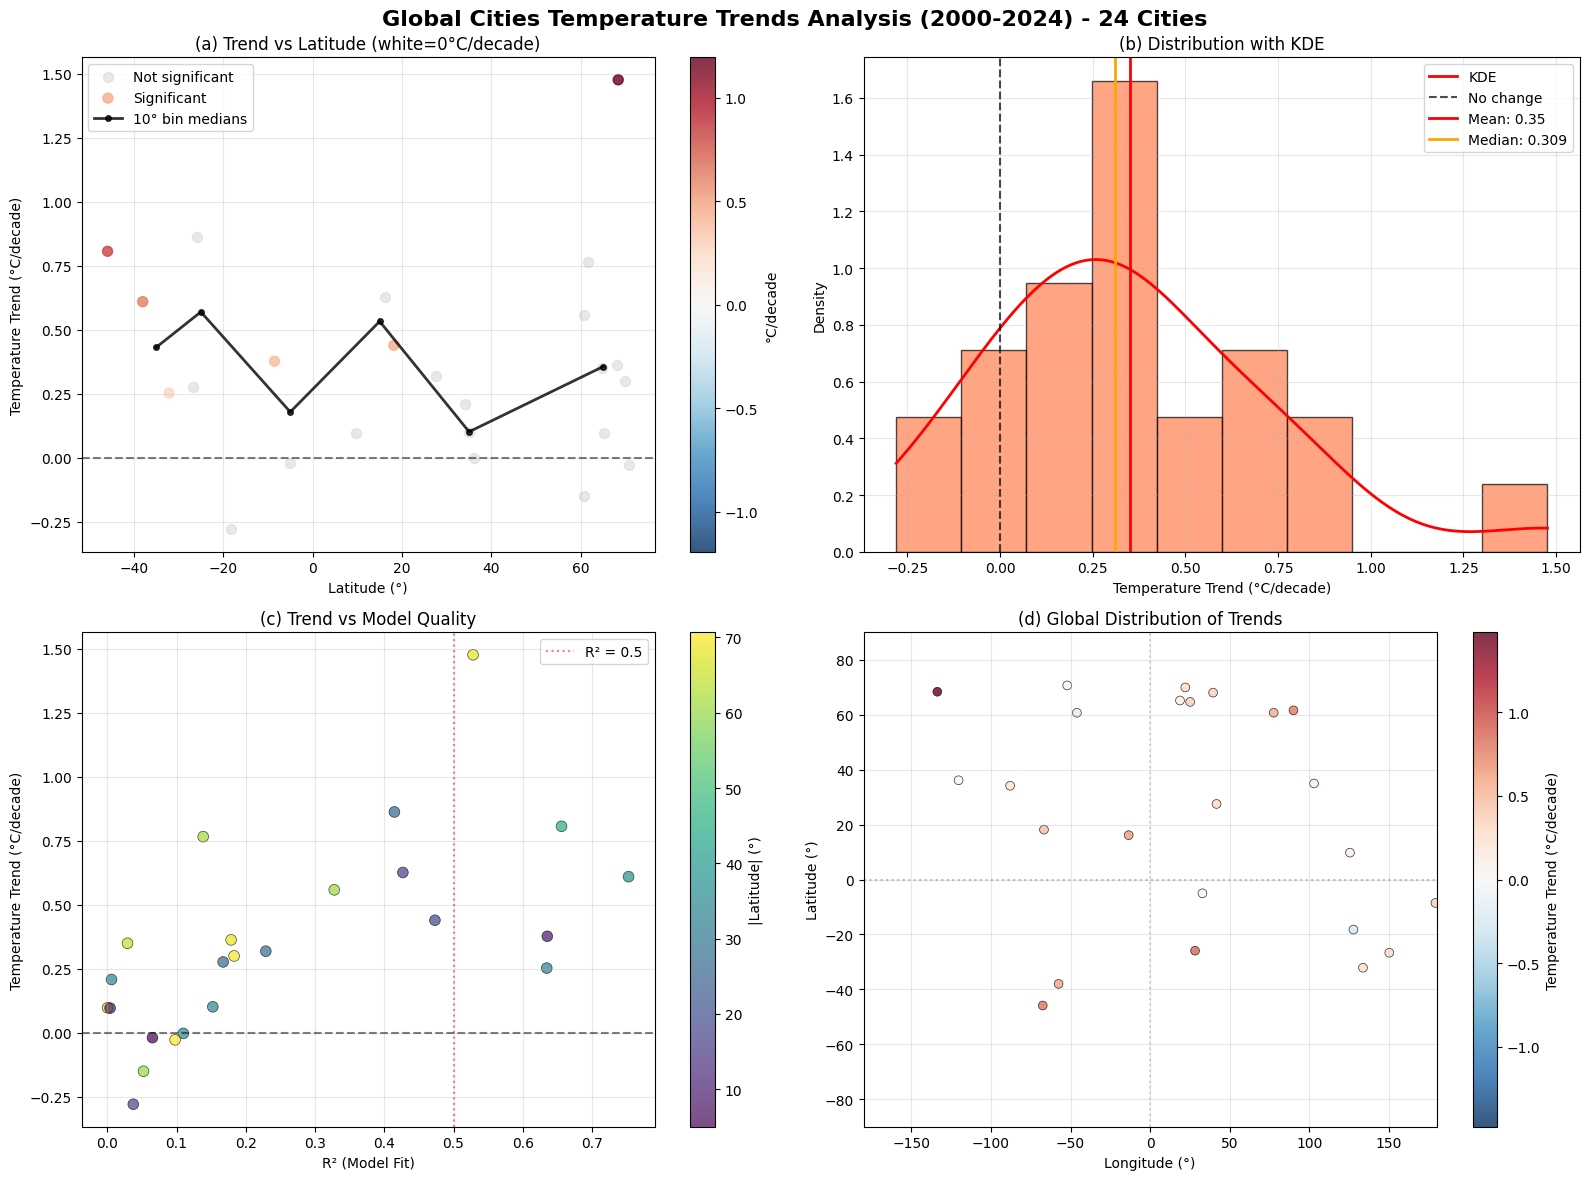

In [9]:
# Visualization now. 

def create_overview_figure(trends_df, mean_trend, median_trend):

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Global Cities Temperature Trends Analysis (2000-2024) - " + str(len(trends_df)) + " Cities",
        fontsize=16, fontweight="bold"
    )

    # trend vs latitude with binned medians
    ax1 = axes[0, 0]


    
    trend_values = trends_df["temp_trend_per_decade"]
    vmax = abs(trend_values).quantile(0.98)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)


    point_size = max(20, 60 - len(trends_df) // 3)
    significant = trends_df[trends_df["significant_05"]]
    not_significant = trends_df[~trends_df["significant_05"]]

    if len(not_significant) > 0:
        ax1.scatter(
            not_significant["latitude"], not_significant["temp_trend_per_decade"],
            c="lightgray", s=point_size, alpha=0.5, label="Not significant"
        )

    if len(significant) > 0:
        scatter = ax1.scatter(
            significant["latitude"], significant["temp_trend_per_decade"],
            c=significant["temp_trend_per_decade"], cmap="RdBu_r", norm=norm,
            s=point_size, alpha=0.8, label="Significant"
        )
        plt.colorbar(scatter, ax=ax1, label="°C/decade")

 
    lat_bins = np.arange(-90, 91, 10) 
    bin_centers = []
    bin_medians = []

    for i in range(len(lat_bins)-1):
        bin_data = trends_df[
            (trends_df["latitude"] >= lat_bins[i]) & 
            (trends_df["latitude"] < lat_bins[i+1])
        ]["temp_trend_per_decade"]

        if len(bin_data) >= 2: 
            bin_centers.append((lat_bins[i] + lat_bins[i+1]) / 2)
            bin_medians.append(bin_data.median())

    if bin_centers:
        ax1.plot(bin_centers, bin_medians, 'ko-', linewidth=2, markersize=4, 
                label="10° bin medians", alpha=0.8)

    ax1.axhline(y=0, color="black", linestyle="--", alpha=0.5)
    ax1.set_xlabel("Latitude (°)")
    ax1.set_ylabel("Temperature Trend (°C/decade)")
    ax1.set_title("(a) Trend vs Latitude (white=0°C/decade)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # hstogram with KDE overlay
    ax2 = axes[0, 1]

    n_bins = min(20, max(10, len(trends_df) // 5))

    counts, bins, patches = ax2.hist(
        trends_df["temp_trend_per_decade"], bins=n_bins, 
        alpha=0.7, color="coral", edgecolor="black", density=True
    )

    if len(trends_df) >= 10:
        from scipy.stats import gaussian_kde
        kde_data = trends_df["temp_trend_per_decade"].dropna()
        if len(kde_data) >= 10:
            kde = gaussian_kde(kde_data)
            x_range = np.linspace(kde_data.min(), kde_data.max(), 200)
            ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label="KDE")

    ax2.axvline(x=0, color="black", linestyle="--", alpha=0.7, label="No change")
    ax2.axvline(x=mean_trend, color="red", linestyle="-", linewidth=2,
                label="Mean: " + str(round(mean_trend, 3)))
    ax2.axvline(x=median_trend, color="orange", linestyle="-", linewidth=2,
                label="Median: " + str(round(median_trend, 3)))

    ax2.set_xlabel("Temperature Trend (°C/decade)")
    ax2.set_ylabel("Density")
    ax2.set_title("(b) Distribution with KDE")
    ax2.legend()
    ax2.grid(True, alpha=0.3)



    
    ax3 = axes[1, 0]

    if len(trends_df) > 50:
        
        hb = ax3.hexbin(
            trends_df["r_squared"], trends_df["temp_trend_per_decade"],
            gridsize=20, cmap="YlOrRd", mincnt=1
        )
        plt.colorbar(hb, ax=ax3, label="City count")
    else:
       
        scatter3 = ax3.scatter(
            trends_df["r_squared"], trends_df["temp_trend_per_decade"],
            c=abs(trends_df["latitude"]), cmap="viridis", s=60, alpha=0.7,
            edgecolors="black", linewidth=0.5
        )
        plt.colorbar(scatter3, ax=ax3, label="|Latitude| (°)")

    ax3.axhline(y=0, color="black", linestyle="--", alpha=0.5)
    ax3.axvline(x=0.5, color="red", linestyle=":", alpha=0.5, label="R² = 0.5")
    ax3.set_xlabel("R² (Model Fit)")
    ax3.set_ylabel("Temperature Trend (°C/decade)")
    ax3.set_title("(c) Trend vs Model Quality")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

   
    ax4 = axes[1, 1]

    
    vmax = max(abs(trends_df["temp_trend_per_decade"].min()), 
               abs(trends_df["temp_trend_per_decade"].max()))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    # Use longitude from data if available
    if "longitude" in trends_df.columns:
        lon_data = trends_df["longitude"]

    scatter4 = ax4.scatter(
        lon_data, trends_df["latitude"],
        c=trends_df["temp_trend_per_decade"], cmap="RdBu_r", norm=norm,
        s=40, alpha=0.8, edgecolors="black", linewidth=0.5
    )

    ax4.set_xlabel("Longitude (°)")
    ax4.set_ylabel("Latitude (°)")
    ax4.set_title("(d) Global Distribution of Trends")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(-180, 180)
    ax4.set_ylim(-90, 90)

    
    ax4.axhline(y=0, color="gray", linestyle=":", alpha=0.5, label="Equator")
    ax4.axvline(x=0, color="gray", linestyle=":", alpha=0.3, label="Prime Meridian")

    plt.colorbar(scatter4, ax=ax4, label="Temperature Trend (°C/decade)")

    plt.tight_layout()
    return fig


main_fig = create_overview_figure(trends_df, mean_trend, median_trend)
main_fig.savefig("../outputs/figures/temperature_trends_overview.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/2d/bv2drtb15t5d17sk_fmphyxr0000gn/T/ipykernel_99205/3499099662.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_summary = trends_df_bands.groupby("lat_band").agg({


Latitude band trend summary:
               lat_band  n_cities  median_slope  mean_slope  iqr_slope
High Southern (<=-45°S)         1         0.806       0.806      0.000
  Low Southern (0-45°S)         7         0.276       0.297      0.377
  Low Northern (0-45°N)         7         0.208       0.255      0.280
 High Northern (>=45°N)         9         0.349       0.414      0.461


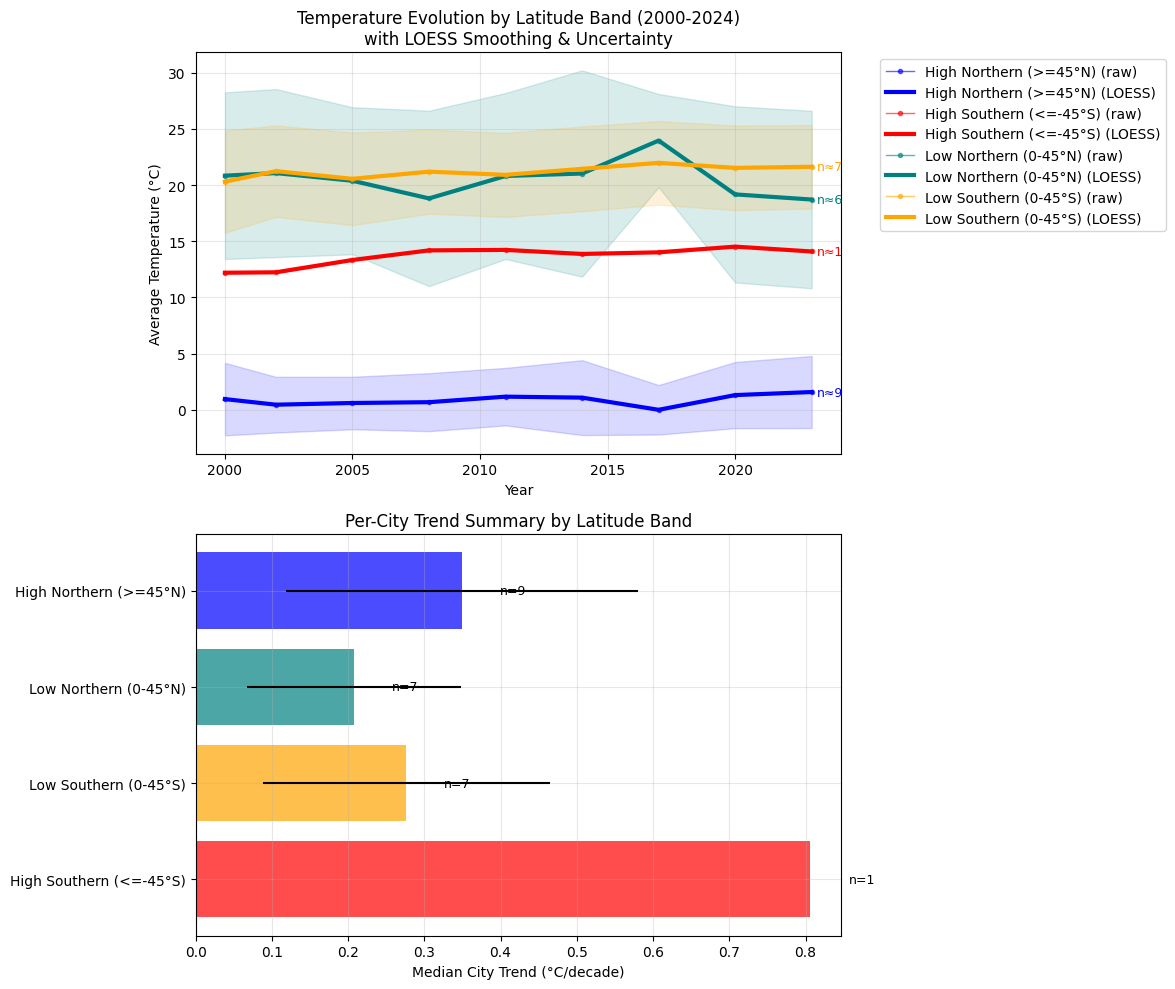

In [10]:
# Make a series plot that shows the latitude bands and how the avg temperature changes over them over the years. added
# an uncertainty band also

def create_timeseries_plot(annual_data, trends_df):
    
    def assign_simple_lat_band(lat):
        if lat >= 45:
            return "High Northern (>=45°N)"
        elif lat >= 0:
            return "Low Northern (0-45°N)"
        elif lat >= -45:
            return "Low Southern (0-45°S)"
        else:
            return "High Southern (<=-45°S)"

    #Band label per city year row 
    annual_data["lat_band_simple"] = annual_data["city_lat"].apply(assign_simple_lat_band)

    # Calculate band averages with uncertainty
    band_trends = annual_data.groupby(["lat_band_simple", "year"]).agg({
        "temp_avg": ["mean", "count", lambda s: s.std(ddof=1)/np.sqrt(len(s)) if len(s) > 1 else np.nan]
    }).reset_index()
    
    band_trends.columns = ["lat_band_simple", "year", "temp_mean", "city_count", "temp_se"]

    trends_df_bands = trends_df.copy()
    trends_df_bands["lat_band"] = pd.cut(
        trends_df_bands["latitude"],
        [-90, -45, 0, 45, 90],
        labels=["High Southern (<=-45°S)", "Low Southern (0-45°S)", 
                "Low Northern (0-45°N)", "High Northern (>=45°N)"]
    )

    band_summary = trends_df_bands.groupby("lat_band").agg({
        "city_name": "count",
        "temp_trend_per_decade": ["median", "mean", lambda s: s.quantile(0.75) - s.quantile(0.25)]
    }).reset_index()
    
    band_summary.columns = ["lat_band", "n_cities", "median_slope", "mean_slope", "iqr_slope"]

    print("Latitude band trend summary:")
    print(band_summary.round(3).to_string(index=False))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # FIXED: Define consistent color mapping that matches both panels
    color_map = {
        "High Northern (>=45°N)": "blue",
        "Low Northern (0-45°N)": "teal", 
        "Low Southern (0-45°S)": "orange",
        "High Southern (<=-45°S)": "red"
    }

    # Top panel - use consistent colors
    for band in band_trends["lat_band_simple"].unique():
        band_data = band_trends[band_trends["lat_band_simple"] == band].sort_values("year")
        color = color_map[band]

        ax1.plot(band_data["year"], band_data["temp_mean"],
                marker="o", linewidth=1, markersize=3, color=color, alpha=0.6,
                label=band + " (raw)")

        valid_se = band_data["temp_se"].notna()
        if valid_se.any():
            band_valid = band_data[valid_se]
            ax1.fill_between(
                band_valid["year"], 
                band_valid["temp_mean"] - 1.96 * band_valid["temp_se"],
                band_valid["temp_mean"] + 1.96 * band_valid["temp_se"],
                alpha=0.15, color=color
            )

        # Loess smoothing
        if len(band_data) >= 5:
            smoothed = lowess(band_data["temp_mean"], band_data["year"], frac=0.3)
            ax1.plot(smoothed[:, 0], smoothed[:, 1],
                    color=color, linestyle="-", linewidth=3,
                    label=band + " (LOESS)")

        median_n = int(np.nanmedian(band_data["city_count"]))
        ax1.text(band_data["year"].iloc[-1] + 0.2, band_data["temp_mean"].iloc[-1],
                "n≈" + str(median_n), fontsize=9, va="center", color=color)

    ax1.set_xlabel("Year")
    ax1.set_ylabel("Average Temperature (°C)")
    ax1.set_title("Temperature Evolution by Latitude Band (2000-2024)\nwith LOESS Smoothing & Uncertainty")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Bottom panel - use same color mapping
    if len(band_summary) > 0:
        # Create colors list that matches the band_summary order
        colors_for_bars = [color_map[band] for band in band_summary["lat_band"]]
        
        ax2.barh(range(len(band_summary)), band_summary["median_slope"], 
                xerr=band_summary["iqr_slope"]/2, alpha=0.7, color=colors_for_bars)
        ax2.set_yticks(range(len(band_summary)))
        ax2.set_yticklabels(band_summary["lat_band"])
        ax2.set_xlabel("Median City Trend (°C/decade)")
        ax2.set_title("Per-City Trend Summary by Latitude Band")
        ax2.axvline(x=0, color="black", linestyle="--", alpha=0.5)
        ax2.grid(True, alpha=0.3)

        # Annotate with sample sizes
        for i, (_, row) in enumerate(band_summary.iterrows()):
            ax2.text(row["median_slope"] + 0.05, i, "n=" + str(int(row["n_cities"])),
                    va="center", fontsize=9)

    plt.tight_layout()
    return fig

timeseries_fig = create_timeseries_plot(annual_data, trends_df)
timeseries_fig.savefig("../outputs/figures/latband_evolution_loess.png", 
                      dpi=300, bbox_inches="tight")
plt.show()

In [11]:

print("Hypothesis testing: \n")


# Test 1: Binomial test for warming prevalence
warming_count = (trends_df["temp_trend_per_decade"] > 0).sum()
total_count = len(trends_df)
binom_result = stats.binomtest(warming_count, n=total_count, p=0.5, alternative="greater")


# Binomial test. is the proportion of warming cities > 50%
print("1. Warming Prevalence (Is the proportion of warming cities > 50%?):")
print("\nObserved:", warming_count, "/", total_count, "(", round(warming_count/total_count * 100, 1), "%)")
print("Binomial test p-value:", binom_result.pvalue, 7)

# Correlation between latitude (absolute) and warming trend
lat = trends_df["latitude"].astype(float).to_numpy()
trend = trends_df["temp_trend_per_decade"].astype(float).to_numpy()
mask = np.isfinite(lat) & np.isfinite(trend)

lat_corr, lat_p = stats.pearsonr(np.abs(lat[mask]), trend[mask])
print("\n2. Latitude and Warming Trend Correlation:")
print("\nCorrelation: r =", round(lat_corr, 4), ", p =", round(lat_p, 4))

# Northern vs southern hemisphere trends of temp chnage
# Welch t-test here coz it allows unequal variance
northern = trends_df.loc[trends_df["latitude"] > 0, "temp_trend_per_decade"].dropna()
southern = trends_df.loc[trends_df["latitude"] < 0, "temp_trend_per_decade"].dropna()

t_stat_ns, p_val_ns = stats.ttest_ind(northern, southern, equal_var=False)
print("\n3. North vs South Hemisphere:")
print("\nt-test: t =", round(t_stat_ns, 3), ", p =", round(p_val_ns, 4))

# High vs low latitude trends
high_lat = trends_df.loc[np.abs(trends_df["latitude"]) > 45, "temp_trend_per_decade"].dropna()
low_lat = trends_df.loc[np.abs(trends_df["latitude"]) <= 45, "temp_trend_per_decade"].dropna()


t_stat_hl, p_val_hl = stats.ttest_ind(high_lat, low_lat, equal_var=False)
print("\n4. High vs Low Latitude:")
print("\nt-test: t =", round(t_stat_hl, 3), ", p =", round(p_val_hl, 4))

# Test 5: One-sample t test to see if the global mean slope > 0. it shuld be!
# one smaple coz im compraign againt zero
td = trends_df["temp_trend_per_decade"].astype(float).dropna()
zero_test_t, zero_test_p = stats.ttest_1samp(td, 0.0)

print("\n5. Global Warming vs Zero:")
print("\nOne-sample t-test: t =", round(zero_test_t, 3), ", p =", zero_test_p)


Hypothesis testing: 

1. Warming Prevalence (Is the proportion of warming cities > 50%?):

Observed: 19 / 24 ( 79.2 %)
Binomial test p-value: 0.003305375576019287 7

2. Latitude and Warming Trend Correlation:

Correlation: r = 0.2102 , p = 0.3242

3. North vs South Hemisphere:

t-test: t = -0.093 , p = 0.9273

4. High vs Low Latitude:

t-test: t = 1.042 , p = 0.3151

5. Global Warming vs Zero:

One-sample t-test: t = 4.463 , p = 0.00017739922125293236


In [12]:
def create_city_data_summary(annual_data):

    city_summary = (
        annual_data
        .groupby(["city_name", "country_code", "city_lat"])
        .agg({
            "year": ["count", "min", "max"],
            "temp_avg": ["mean", "std"],
            "valid_temp_weeks": ["mean"],
        })
        .reset_index()
    )

    # Flatten MultiIndex column names
    city_summary.columns = [
        "city_name",
        "country_code",
        "city_lat",
        "total_years",         
        "first_year",          
        "last_year",           
        "mean_temp",          
        "temp_std",            
        "avg_valid_weeks"     
    ]

   
    city_summary = city_summary.rename(columns={
        "total_years": "Total_Years",
        "first_year": "First_Year",
        "last_year": "Last_Year",
        "mean_temp": "Mean_Temp",
        "temp_std": "Temp_StdDev",
        "avg_valid_weeks": "Avg_Valid_Weeks_Per_Year",
    })

    city_summary = city_summary.round(5)
    return city_summary


In [13]:
# saving all output files

trends_df.to_csv("../outputs/tables/temperature_trends_results.csv", index=False)
annual_data.to_csv("../outputs/tables/annual_temperature_data.csv", index=False)


final_trends = trends_df[[
    "city_name", "country_code", "latitude", "station_distance_km",
    "years_analyzed", "temp_trend_per_decade", "r_squared", "p_value",
    "significant_05", "mean_temp_all_years"
]].copy()
final_trends.to_csv("../outputs/tables/final_temperature_trends.csv", index=False)


city_summary = create_city_data_summary(annual_data)
city_summary.to_csv("../outputs/tables/city_data_summary.csv", index=False)


final_stats = {
    "analysis_date": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "total_cities": len(trends_df),
    "warming_cities": warming_cities,
    "cooling_cities": total_count - warming_cities,
    "significant_trends": trends_df["significant_05"].sum(),
    "mean_warming_rate": mean_trend,
    "median_warming_rate": median_trend,
    "binomial_test_p": binom_result.pvalue,
    "latitude_correlation": lat_corr,
    "latitude_correlation_p": lat_p,
    "zero_trend_test_p": zero_test_p,
}


final_stats = fix_json_export(final_stats)

with open("../outputs/final_analysis_stats.json", "w") as f:
    json.dump(final_stats, f, indent=2)


print("All outputs saved to '../outputs/' directory")



All outputs saved to '../outputs/' directory


In [14]:

print("Validation summary:")
print("Date range:", annual_data['year'].min(), "-", annual_data['year'].max())
print("Total records:", len(annual_data))
print("Cities analyzed:", annual_data['city_name'].nunique())


print("Mean global trend:", round(mean_trend, 3), "degC/decade")
print("Analysis validation complete.")



Validation summary:
Date range: 2000 - 2023
Total records: 201
Cities analyzed: 24
Mean global trend: 0.35 degC/decade
Analysis validation complete.
